# Task 2: Data Profiling, Cleaning & EDA - Benin

**Objective:**  
Profile, clean, and explore Benin's solar dataset end-to-end to prepare it for comparison and region-ranking tasks.

## 0. Setup and Data Loading
First, let's set up our environment and load the data.


Part 1: Initial Setup and Data Loading
Cell 1: Import Libraries and Configure Settings
This cell imports the necessary Python libraries and sets up the default styles for our visualizations to ensure clarity and consistency.

In [24]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

**Explanation:**

- We import `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib.pyplot` & `seaborn` for plotting.
- `warnings.filterwarnings('ignore')` helps keep the output clean by suppressing unnecessary warnings.
- `sns.set_style("whitegrid")` and `plt.rcParams` configure plot aesthetics for better readability.
- We attempt to load `Benin-data.csv` with error handling in case the file isn't found.
- `df.info()` gives us a summary of column names, non-null counts, and data types — our first step in identifying data types and detecting missing values.
- `df.head()` displays the first few rows to get a glimpse of the data structure.


In [25]:
# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set aesthetic style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [26]:
# Load the dataset for Benin
try:
    df = pd.read_csv('../data/togo_eda.csv')
    print("Benin data loaded successfully!")
except FileNotFoundError:
    print("Error: 'togo.csv' not found. Please ensure the file is in the 'data/' directory.")
    # Create an empty DataFrame to prevent errors in subsequent steps
    df = pd.DataFrame() 


Benin data loaded successfully!


In [27]:
# Display initial information about the dataset
if not df.empty:
    print("\nInitial DataFrame Info:")
    df.info()
    print("\nFirst 5 rows of the dataset:")
    print(df.head())


Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516349 entries, 0 to 516348
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      516349 non-null  object 
 1   GHI            516349 non-null  float64
 2   DNI            516349 non-null  float64
 3   DHI            516349 non-null  float64
 4   ModA           516349 non-null  float64
 5   ModB           516349 non-null  float64
 6   Tamb           516349 non-null  float64
 7   RH             516349 non-null  float64
 8   WS             516349 non-null  float64
 9   WSgust         516349 non-null  float64
 10  WSstdev        516349 non-null  float64
 11  WD             516349 non-null  float64
 12  WDstdev        516349 non-null  float64
 13  BP             516349 non-null  int64  
 14  Cleaning       516349 non-null  int64  
 15  Precipitation  516349 non-null  float64
 16  TModA          516349 non-null  float64
 17  TMod

In [28]:
# Display initial information about the dataset
if not df.empty:
    print("\nInitial DataFrame Info:")
    df.info()
    print("\nFirst 5 rows of the dataset:")
    print(df.tail())

df.tail(5)


Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516349 entries, 0 to 516348
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      516349 non-null  object 
 1   GHI            516349 non-null  float64
 2   DNI            516349 non-null  float64
 3   DHI            516349 non-null  float64
 4   ModA           516349 non-null  float64
 5   ModB           516349 non-null  float64
 6   Tamb           516349 non-null  float64
 7   RH             516349 non-null  float64
 8   WS             516349 non-null  float64
 9   WSgust         516349 non-null  float64
 10  WSstdev        516349 non-null  float64
 11  WD             516349 non-null  float64
 12  WDstdev        516349 non-null  float64
 13  BP             516349 non-null  int64  
 14  Cleaning       516349 non-null  int64  
 15  Precipitation  516349 non-null  float64
 16  TModA          516349 non-null  float64
 17  TMod

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
516344,2022-10-24 23:56:00,430.3,0.0,0.0,0.0,0.0,25.2,53.8,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.3,24.0,NaN
516345,2022-10-24 23:57:00,430.3,0.0,0.0,0.0,0.0,25.3,53.5,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.3,24.0,NaN
516346,2022-10-24 23:58:00,430.3,0.0,0.0,0.0,0.0,25.3,53.4,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.2,23.9,NaN
516347,2022-10-24 23:59:00,430.3,0.0,0.0,0.0,0.0,25.4,53.5,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.1,23.8,NaN
516348,2022-10-25 00:00:00,430.3,0.0,0.0,0.0,0.0,25.4,52.3,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.1,23.8,NaN


In [29]:
if not df.empty:
    print("--- Initial Data Types of Raw Data ---")
    print(df.dtypes)

--- Initial Data Types of Raw Data ---
Timestamp         object
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object


In [30]:
if not df.empty:
    print("\n--- Initial Summary Statistics (including non-numeric columns) ---")
    print(df.describe(include='all'))


--- Initial Summary Statistics (including non-numeric columns) ---
                  Timestamp           GHI            DNI            DHI  \
count                516349  516349.00000  516349.000000  516349.000000   
unique               516349           NaN            NaN            NaN   
top     2021-10-25 00:01:00           NaN            NaN            NaN   
freq                      1           NaN            NaN            NaN   
mean                    NaN     438.27124     147.975931     112.781249   
std                     NaN     224.64318     247.683690     151.571744   
min                     NaN       0.00000       0.000000       0.000000   
25%                     NaN     412.90000       0.000000       0.000000   
50%                     NaN     430.30000       0.000000       1.500000   
75%                     NaN     430.30000     237.900000     211.600000   
max                     NaN    1198.00000     904.100000     586.000000   

                 ModA          

In [31]:
if not df.empty:
    print("\n--- Initial Missing Value Report ---")
    missing_values = df.isna().sum()
    missing_percentage = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
    
    # Display only columns that have missing values
    print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))


--- Initial Missing Value Report ---
          Missing Count  Missing Percentage
Comments         516349               100.0


In [32]:
if not df.empty:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    print(f"'Timestamp' column successfully converted to datetime format.")

'Timestamp' column successfully converted to datetime format.


In [33]:
if not df.empty:
    numeric_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust',
                    'WSstdev', 'WD', 'WDstdev', 'BP', 'Precipitation', 'TModA', 'TModB']
    
    print("\nConverting relevant columns to numeric type...")
    for col in numeric_cols:
        if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"  - Column '{col}' converted to numeric.")


Converting relevant columns to numeric type...


In [34]:
if not df.empty and 'Cleaning' in df.columns:
    df['Cleaning'] = df['Cleaning'].astype('category')
    print(f"'Cleaning' column converted to category format.")

'Cleaning' column converted to category format.


In [35]:
if not df.empty:
    print("\n--- Missing Value Report After Type Conversion ---")
    missing_values = df.isna().sum()
    missing_percentage = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
    
    print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))


--- Missing Value Report After Type Conversion ---
          Missing Count  Missing Percentage
Comments         516349               100.0


In [36]:
if not df.empty:
    print("\n--- DataFrame Info After Type Conversions ---")
    df.info()


--- DataFrame Info After Type Conversions ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516349 entries, 0 to 516348
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      516349 non-null  datetime64[ns]
 1   GHI            516349 non-null  float64       
 2   DNI            516349 non-null  float64       
 3   DHI            516349 non-null  float64       
 4   ModA           516349 non-null  float64       
 5   ModB           516349 non-null  float64       
 6   Tamb           516349 non-null  float64       
 7   RH             516349 non-null  float64       
 8   WS             516349 non-null  float64       
 9   WSgust         516349 non-null  float64       
 10  WSstdev        516349 non-null  float64       
 11  WD             516349 non-null  float64       
 12  WDstdev        516349 non-null  float64       
 13  BP             516349 non-null  int64         
 14  Clean

In [37]:
if not df.empty:
    print("\n--- Missing Value Report After Type Conversion ---")
    missing_values = df.isna().sum()
    missing_percentage = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
    
    print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))


--- Missing Value Report After Type Conversion ---
          Missing Count  Missing Percentage
Comments         516349               100.0


In [38]:
if not df.empty:
    print("\nDetecting Outliers using Z-scores (|Z| > 3):")
    outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust', 'Tamb', 'TModA']
    
    for col in outlier_cols:
        if col in df.columns and df[col].std() != 0:
            df[f'Zscore_{col}'] = (df[col] - df[col].mean()) / df[col].std()
            outlier_count = (abs(df[f'Zscore_{col}']) > 3).sum()
            if outlier_count > 0:
                print(f"  - Found {outlier_count} outliers in '{col}'.")


Detecting Outliers using Z-scores (|Z| > 3):
  - Found 848 outliers in 'GHI'.
  - Found 386 outliers in 'DNI'.
  - Found 1422 outliers in 'DHI'.
  - Found 10 outliers in 'ModA'.
  - Found 66 outliers in 'ModB'.
  - Found 944 outliers in 'WS'.
  - Found 638 outliers in 'WSgust'.
  - Found 181 outliers in 'TModA'.


In [39]:
if not df.empty:
    initial_rows = len(df)
    critical_outlier_cols = ['GHI', 'DNI', 'DHI']
    
    for col in critical_outlier_cols:
        if f'Zscore_{col}' in df.columns:
            df = df[(abs(df[f'Zscore_{col}']) <= 3) | (df[f'Zscore_{col}'].isna())]
            
    print(f"Removed {initial_rows - len(df)} rows containing critical outliers.")

Removed 2634 rows containing critical outliers.


In [41]:
if not df.empty:
    print("\nImputing all remaining missing values...")
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if pd.api.types.is_numeric_dtype(df[col]):
                # Impute numeric columns with the median
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f"  - Numeric column '{col}': Imputed with median ({median_val:.2f}).")
            else:
                # Impute categorical/object columns with the mode
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f"  - Categorical column '{col}': Imputed with mode ('{mode_val}').")


Imputing all remaining missing values...
  - Numeric column 'Comments': Imputed with median (nan).


In [42]:
if not df.empty:
    zscore_cols_to_drop = [col for col in df.columns if 'Zscore_' in col]
    df.drop(columns=zscore_cols_to_drop, inplace=True)
    print("Temporary Z-score columns removed.")
    
    if 'Comments' in df.columns:
        df.drop(columns=['Comments'], inplace=True)
        print("'Comments' column dropped.")

Temporary Z-score columns removed.
'Comments' column dropped.


In [44]:
if not df.empty:
    print("\n--- Final Verification of Data Cleanliness ---")
    
    # Calculate the total number of remaining missing values
    total_missing = df.isna().sum().sum()
    
    if total_missing == 0:
        print("Success! No missing values remain in the dataset.")
        print("\nFinal DataFrame Info:")
        df.info()
    else:
        print("Warning! Missing values still exist:")
        # This will now execute correctly without the syntax error
        print(df.isna().sum()[df.isna().sum() > 0])


--- Final Verification of Data Cleanliness ---
Success! No missing values remain in the dataset.

Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 513715 entries, 0 to 516348
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      513715 non-null  datetime64[ns]
 1   GHI            513715 non-null  float64       
 2   DNI            513715 non-null  float64       
 3   DHI            513715 non-null  float64       
 4   ModA           513715 non-null  float64       
 5   ModB           513715 non-null  float64       
 6   Tamb           513715 non-null  float64       
 7   RH             513715 non-null  float64       
 8   WS             513715 non-null  float64       
 9   WSgust         513715 non-null  float64       
 10  WSstdev        513715 non-null  float64       
 11  WD             513715 non-null  float64       
 12  WDstdev        513715 non-null  float64 

In [47]:
if not df.empty:
    output_path = '../data/togo_eda.csv'
    df.to_csv(output_path, index=False)
    print(f"\nCleaned DataFrame exported successfully to '{output_path}'")


Cleaned DataFrame exported successfully to '../data/togo_eda.csv'


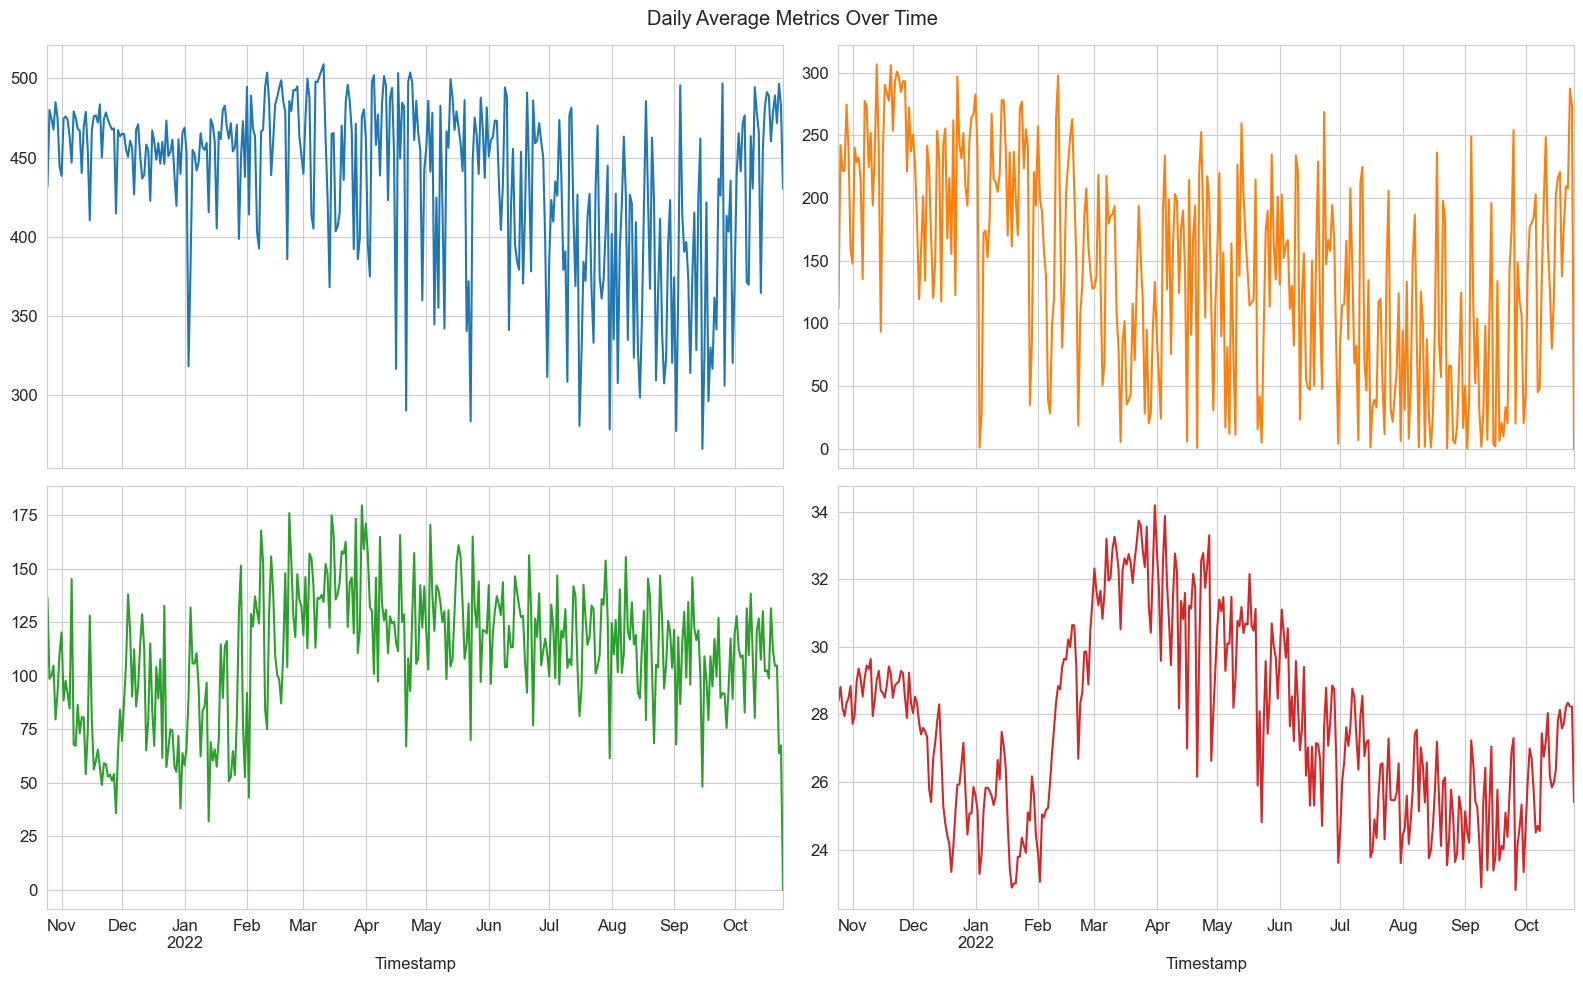

In [48]:
if not df.empty:
    df_ts = df.set_index('Timestamp')
    df_daily = df_ts.resample('D').mean(numeric_only=True)

    df_daily[['GHI', 'DNI', 'DHI', 'Tamb']].plot(
        subplots=True, 
        layout=(2, 2), 
        figsize=(16, 10),
        title='Daily Average Metrics Over Time',
        legend=False
    )
    plt.tight_layout()
    plt.show()

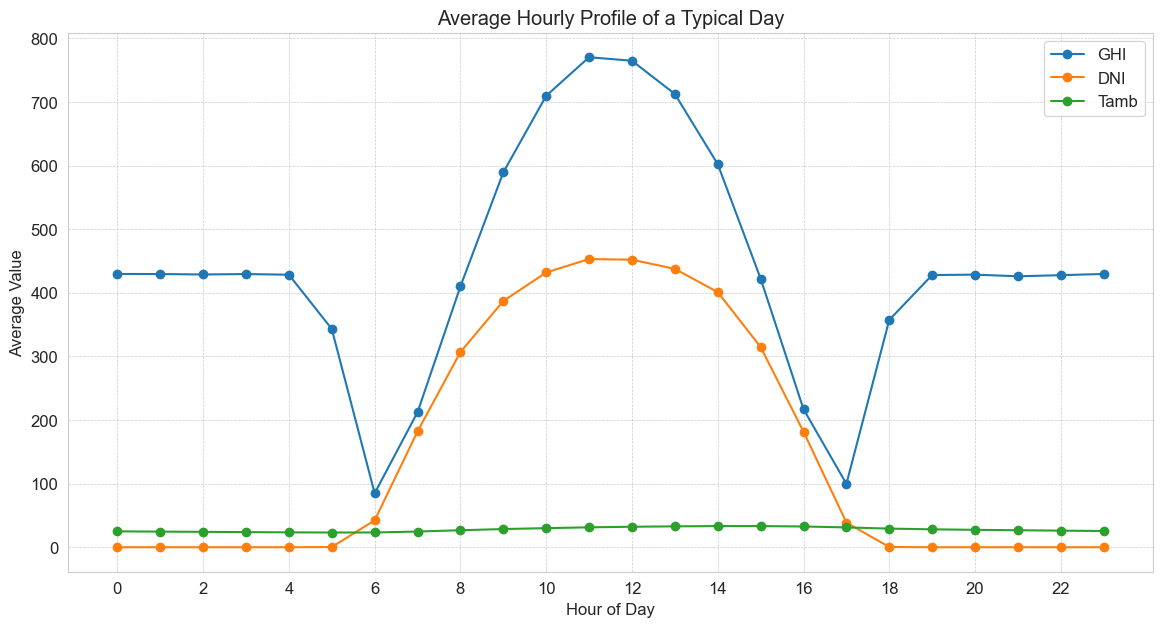

In [49]:
if not df.empty:
    df_hourly_avg = df.set_index('Timestamp').groupby(lambda x: x.hour).mean(numeric_only=True)
    
    df_hourly_avg[['GHI', 'DNI', 'Tamb']].plot(
        figsize=(14, 7), 
        marker='o',
        title='Average Hourly Profile of a Typical Day'
    )
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Value')
    plt.xticks(range(0, 24, 2))
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

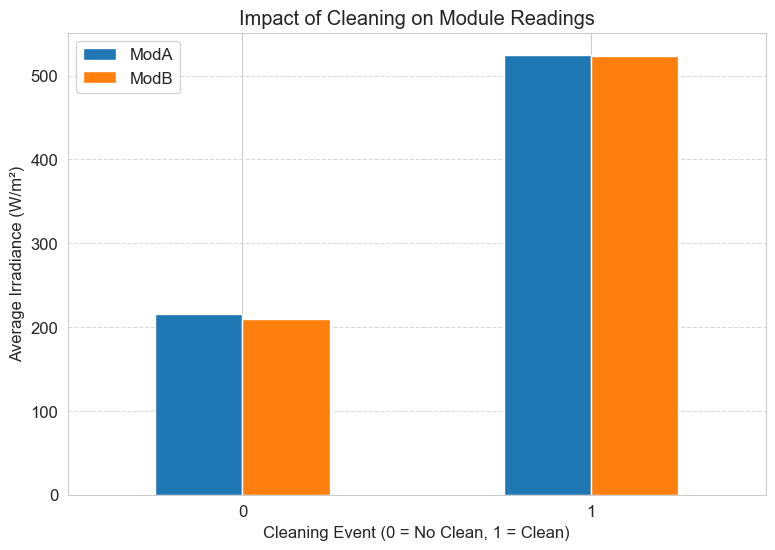

In [50]:
if not df.empty and 'Cleaning' in df.columns:
    cleaning_impact = df.groupby('Cleaning')[['ModA', 'ModB']].mean(numeric_only=True)
    
    cleaning_impact.plot(kind='bar', figsize=(9, 6))
    plt.title('Impact of Cleaning on Module Readings')
    plt.ylabel('Average Irradiance (W/m²)')
    plt.xlabel('Cleaning Event (0 = No Clean, 1 = Clean)')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

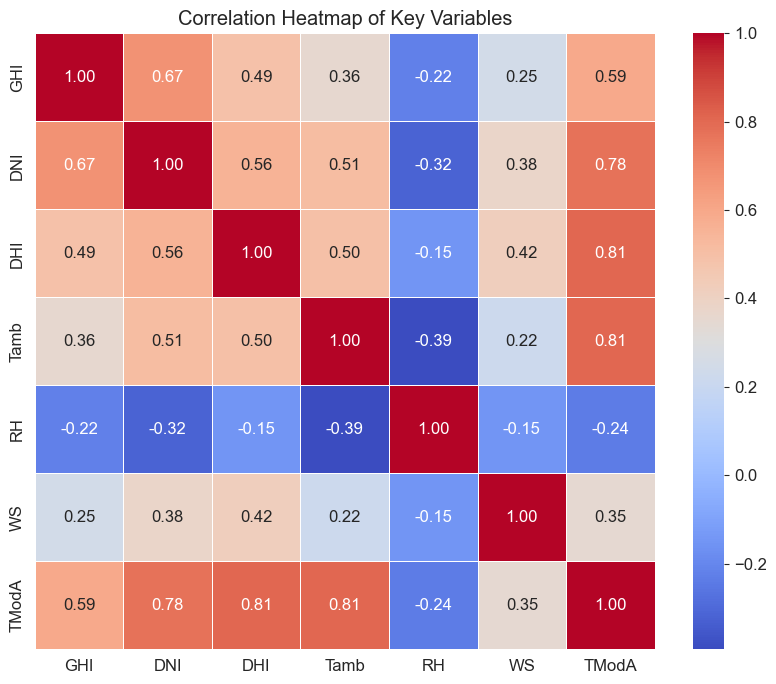

In [51]:
if not df.empty:
    correlation_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'WS', 'TModA']
    correlation_matrix = df[correlation_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Heatmap of Key Variables')
    plt.show()

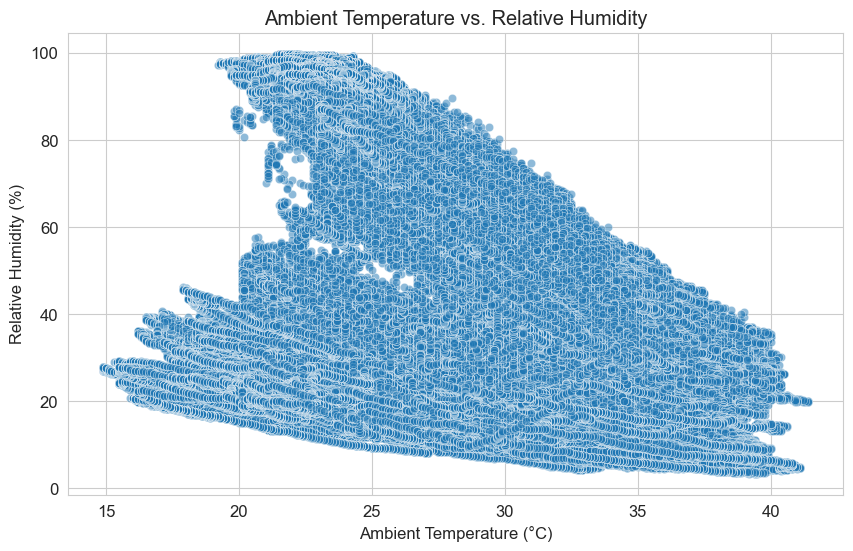

In [52]:
if not df.empty:
    sns.scatterplot(data=df, x='Tamb', y='RH', alpha=0.5)
    plt.title('Ambient Temperature vs. Relative Humidity')
    plt.xlabel('Ambient Temperature (°C)')
    plt.ylabel('Relative Humidity (%)')
    plt.show()

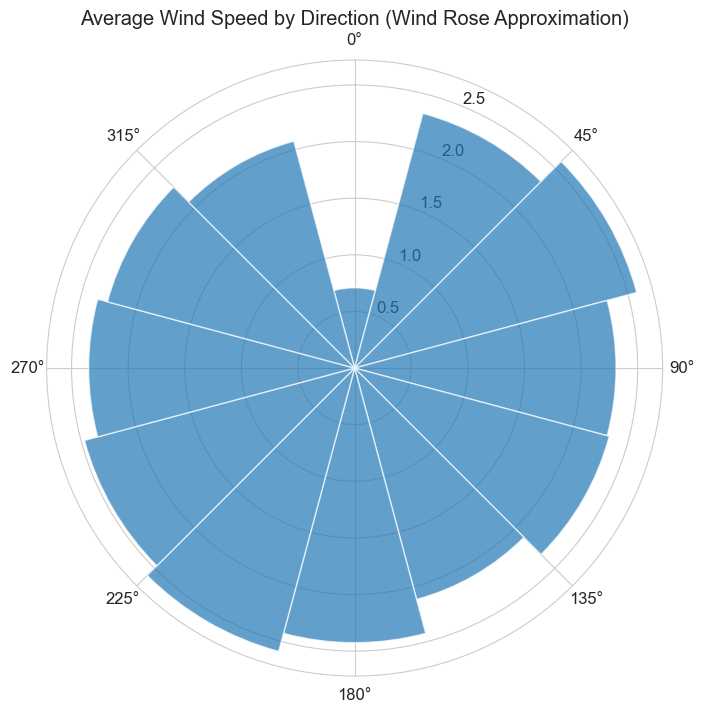

In [53]:
if not df.empty:
    bins = np.arange(0, 361, 30)
    df['WD_Bin'] = pd.cut(df['WD'], bins=bins, right=False, labels=np.arange(0, 360, 30))
    avg_ws_by_wd = df.groupby('WD_Bin')['WS'].mean().fillna(0)

    plt.figure(figsize=(10, 8))
    ax = plt.subplot(111, projection='polar')
    ax.bar(np.radians(avg_ws_by_wd.index.astype(float)), avg_ws_by_wd.values, width=np.radians(30), alpha=0.7)
    
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title('Average Wind Speed by Direction (Wind Rose Approximation)')
    plt.show()

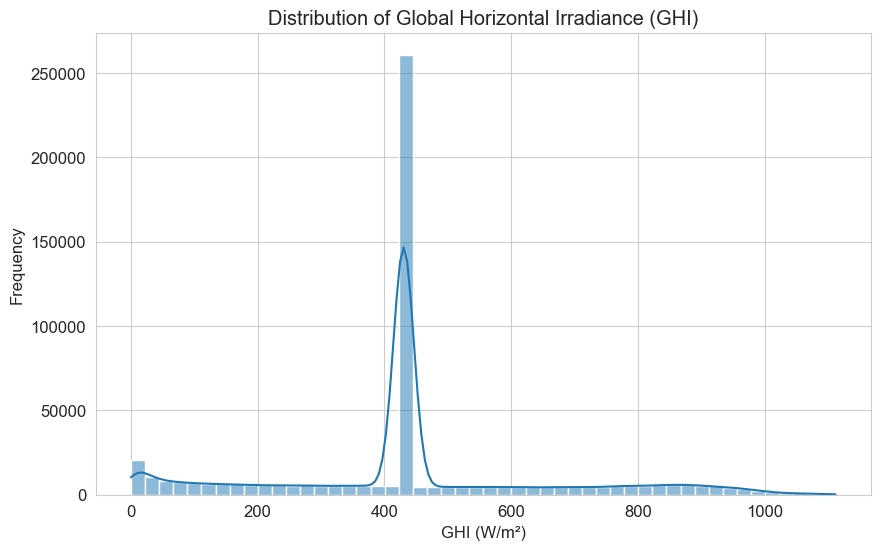

In [54]:
if not df.empty:
    sns.histplot(data=df, x='GHI', kde=True, bins=50)
    plt.title('Distribution of Global Horizontal Irradiance (GHI)')
    plt.xlabel('GHI (W/m²)')
    plt.ylabel('Frequency')
    plt.show()

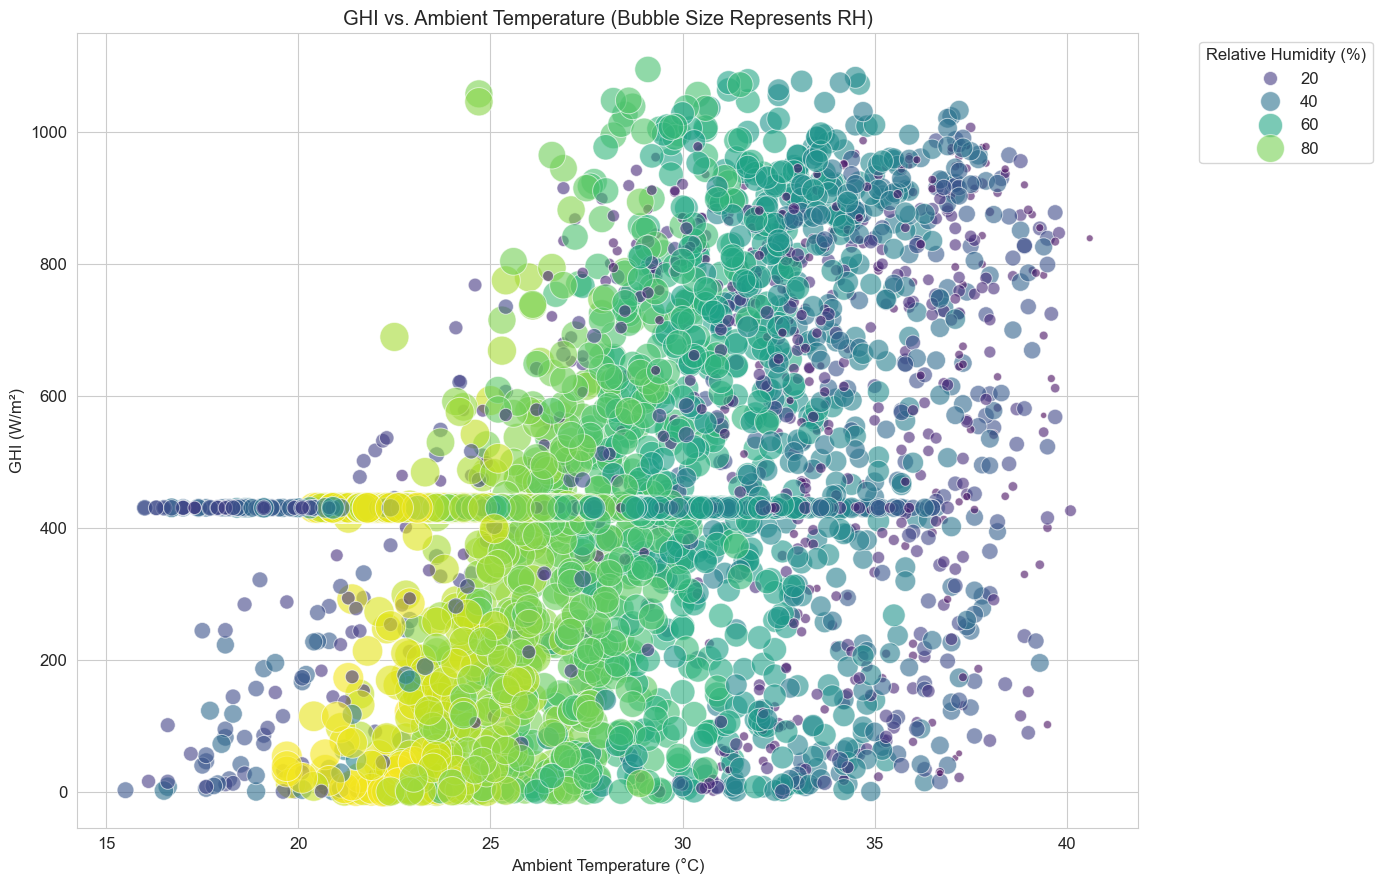

In [55]:
if not df.empty:
    sample_df = df.sample(n=min(5000, len(df)), random_state=42)
    
    plt.figure(figsize=(14, 9))
    sns.scatterplot(
        data=sample_df,
        x='Tamb',
        y='GHI',
        size='RH',
        hue='RH',
        sizes=(20, 500),
        alpha=0.6,
        palette='viridis'
    )
    plt.title('GHI vs. Ambient Temperature (Bubble Size Represents RH)')
    plt.xlabel('Ambient Temperature (°C)')
    plt.ylabel('GHI (W/m²)')
    plt.legend(title='Relative Humidity (%)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()